# Lab 5: Clustering

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

1.  You are given the following 2D data points. Apply K-Means clustering and use the 
Elbow Method to determine the optimal number of clusters. [1, 2], [2, 3], [3, 3],  [10, 12], [11, 13], [12, 14],[25, 30], [26, 29], [27, 28]

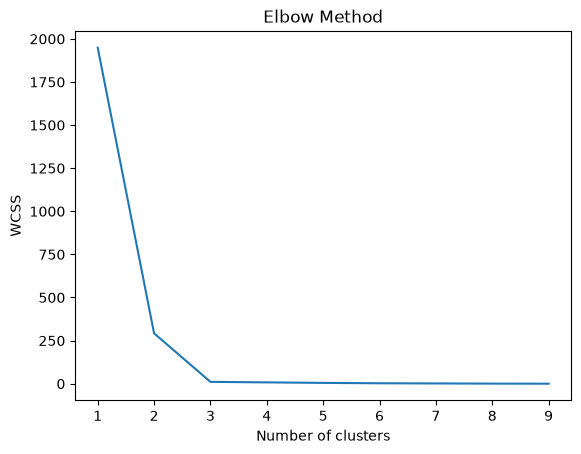

In [26]:
#1. Find the number of clusters using the elbow method.
# Plots WCSS (Within-Cluster Sum of Squares) against different k values

X = np.array([[1, 2], [2, 3], [3, 3],
              [10, 12], [11, 13], [12, 14],
              [25, 30], [26, 29], [27, 28]])
wcss = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 10), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


In [27]:
# fit the kmeans with clusters = 3 by elbow method
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=0)
y_kmeans = kmeans.fit_predict(X)
print(y_kmeans)

[2 2 2 0 0 0 1 1 1]


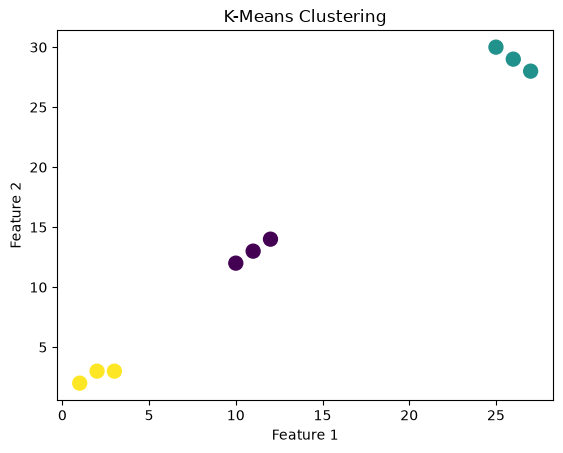

In [28]:
#plot the data points

plt.scatter(X[:, 0], X[:, 1], s=100, c=y_kmeans, label='Data Points')
plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

2. Perform agglomerative hierarchical clustering on the following data points. Plot 
the dendrogram and identify the optimal number of clusters.

In [29]:
data_points = np.array([[1, 1], [2, 1], [1, 2], [8, 8], [9, 9], [8, 9], [4, 7], [5, 6]])

hierarchical = AgglomerativeClustering(n_clusters=3)
y_hierarchical = hierarchical.fit_predict(data_points)
print(y_hierarchical)

[1 1 1 2 2 2 0 0]


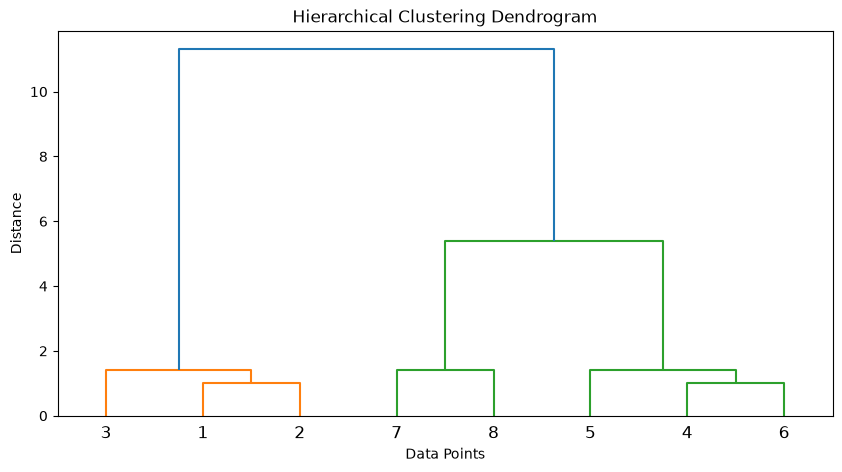

In [30]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(data_points, method='complete')
plt.figure(figsize=(10, 5))

dendrogram(Z, labels=np.arange(1, len(data_points) + 1))
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

3. Apply the DBSCAN algorithm to find core, border, and noise points from the 
following spatial dataset. [1, 2], [1.1, 2.1], [0.9, 1.8], [1.2, 2.2], [8, 8], [8.1, 8.2], [8.2, 7.9], [5, 5] 

In [31]:
X_data = np.array([[1, 2], [1.1, 2.1], [0.9, 1.8], [1.2, 2.2], [8, 8], [8.1, 8.2], [8.2, 7.9], [5, 5]])

dbscan_clustering = DBSCAN(eps=0.5, min_samples=2)
dbscan_labels = dbscan_clustering.fit_predict(X_data)

core_indices = dbscan_clustering.core_sample_indices_

#core points 
core_points = X_data[core_indices]
print(f"Core Points: {core_points}")

#noise points
noise_points = X_data[dbscan_labels == -1]
print(f"Noise Points: {noise_points}")

# border points
border_points = X_data[(dbscan_labels != -1) & (~np.isin(np.arange(len(X_data)), core_indices))]
print(f"Border Points: {border_points}")

Core Points: [[1.  2. ]
 [1.1 2.1]
 [0.9 1.8]
 [1.2 2.2]
 [8.  8. ]
 [8.1 8.2]
 [8.2 7.9]]
Noise Points: [[5. 5.]]
Border Points: []
